# YYW full-geometric affine fitting

Fit the previously analyzed `55A_R0`, `55B_R0`, and `55C_R0` curves with the second-order geometric affine correction and the independent heterogeneous mask. Existing YYW affine results seed $k_{\rm eff}$, the radial-distribution width, the heterogeneous parameters, and the incompressible uniaxial stretch.

The physical-line spectrum is stretched first and the independent heterogeneous mask operator is then applied to it. Each sample is fitted once from the current YYW result, retaining the high-$Q$ coefficient anchor used by the earlier workflow and adding no `LineFitConstraints`.


In [1]:
from pathlib import Path
import csv

import matplotlib.pyplot as plt
import numpy as np

import cf_tools as cf

plt.rcParams.update({"figure.dpi": 130, "savefig.dpi": 200, "axes.grid": True, "grid.alpha": 0.25})

def load_parameter_csv(path):
    with Path(path).open(newline="", encoding="utf-8") as handle:
        return {row["name"]: float(row["value"]) for row in csv.DictReader(handle)}

def load_profile_csv(path, label):
    table = np.loadtxt(path, delimiter=",", skiprows=1)
    table = np.atleast_2d(table)
    return cf.RadialProfile(label=label, q=table[:, 0], intensity=table[:, 1], error=table[:, 2], count=table[:, 3].astype(int))


## Inputs and numerical controls

In [2]:
PREVIOUS_OUTPUT_DIR = Path("output/yyw")
OUTPUT_DIR = Path("output/yyw/aniso")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_MODE = "heterogeneous"
K_DISTRIBUTION = "gaussian_radial"  # "gaussian_radial" or "gamma_radial"
K_SCALE_CONVENTION = "k_eff"
STRETCH_MODEL = "full_geom"  # "spectrum" or "full_geom"
AFFINE_MODEL = {"spectrum": "scalar", "full_geom": "geometric_second_order"}[STRETCH_MODEL]
if MODEL_MODE not in {"line_only", "heterogeneous"}:
    raise ValueError("MODEL_MODE must be line_only or heterogeneous")
FIT_TAG = f"{K_DISTRIBUTION}_{STRETCH_MODEL}_OH2"

SAMPLES = {
    tag: {
        "observation": PREVIOUS_OUTPUT_DIR/f"{tag}_stitched_observation.csv",
        "fallback_parameters": PREVIOUS_OUTPUT_DIR/f"{tag}_first_fit_parameters.csv",
        "current_parameters": OUTPUT_DIR/f"{tag}_gaussian_affine_fit_parameters.csv",
    }
    for tag in ("55A_R0", "55B_R0", "55C_R0")
}
for tag, files in SAMPLES.items():
    for kind in ("observation", "fallback_parameters"):
        if not files[kind].exists():
            raise FileNotFoundError(f"Missing previous {kind} for {tag}: {files[kind]}")

FIT_Q_BOUNDS = (1.5e-3, 4.0e-1)
HIGHQ_ANCHOR_BOUNDS = (8.0e-2, 4.0e-1)
LOG_ERROR_FLOOR = 0.04
STRETCH_INITIAL = 1.2
RUN_FITS = True
MAX_NFEV = 80
HIGHQ_ANCHOR_WEIGHT = 1.0

fit_model_settings = {
    "k_distribution": K_DISTRIBUTION, "k_scale_convention": K_SCALE_CONVENTION,
    "k_sampling": "quadrature", "regression_loss": "relative",
    "num_modes_k": 2**9, "Nr": 3000, "Nr_small": 600,
    "r_min_factor": 1e-3, "r_split_factor": 5.0, "r_max_factor": 250.0,
    "N_samp_U": 2**12, "N_samp_st": 2**7, "NQ": 220,
    "powder_n_mu": 64, "affine_model": AFFINE_MODEL,
    "N_samp_tangent": 2**12, "tangent_use_qmc": True,
    "tangent_random_seed": 12345, "derivative_smoothing_fraction": 1e-2,
    "tangent_tail_start_factor": 40.0, "tangent_tail_end_factor": 80.0,
    "progress": False,
}
distribution_parameter_set = {"r_sigma_k": {"initial": 0.27, "bounds": (0.06, 0.90)}}


## Load current fits and construct full-geometric initial models

In [3]:
profiles = {}
seed_parameters = {}
fit_initials = {}
fit_bounds_by_sample = {}
anchors = {}
initial_models = {}

for tag, files in SAMPLES.items():
    profile = load_profile_csv(files["observation"], tag)
    seed_path = files["current_parameters"] if files["current_parameters"].exists() else files["fallback_parameters"]
    previous = load_parameter_csv(seed_path)
    profiles[tag] = profile
    seed_parameters[tag] = previous
    seed_width = float(previous["r_sigma_k"])
    seed_k_eff = float(previous.get("k_eff", previous["mean_k"]*np.sqrt(1.0+seed_width**2)))
    initial = {
        "k_eff": seed_k_eff,
        "r_sigma_k": seed_width,
        "stretch_ratio": float(previous.get("stretch_ratio", STRETCH_INITIAL)),
    }
    if MODEL_MODE == "heterogeneous":
        initial["k_H_over_k"] = float(previous["k_H_over_k"])
        initial["b"] = float(previous["b"])
    if tag == "55A_R0":
        initial["r_sigma_k"] = min(initial["r_sigma_k"], 0.24)
        r_sigma_bounds = (0.06, 0.25)
    else:
        r_sigma_bounds = distribution_parameter_set["r_sigma_k"]["bounds"]
    fit_initials[tag] = initial
    fit_bounds_by_sample[tag] = {
        "k_eff": (max(0.005, 0.45*initial["k_eff"]), min(0.5, 2.2*initial["k_eff"])),
        "r_sigma_k": r_sigma_bounds,
        "stretch_ratio": (0.85, 1.65),
    }
    if MODEL_MODE == "heterogeneous":
        fit_bounds_by_sample[tag].update({
            "k_H_over_k": (max(1e-4, 0.25*initial["k_H_over_k"]), min(0.5, 4.0*initial["k_H_over_k"])),
            "b": (-4.0, 2.0),
        })
    anchors[tag] = {
        "high": cf.fit_highq_line_anchor(profile, HIGHQ_ANCHOR_BOUNDS, background_max=0.0),
    }
    sample_distribution_set = {"r_sigma_k": {"initial": initial["r_sigma_k"], "bounds": r_sigma_bounds}}
    initial_models[tag] = cf.evaluate_heterogeneous_line_guess(
        profile, q_bounds=FIT_Q_BOUNDS, parameters=initial, model_mode=MODEL_MODE,
        model_settings=fit_model_settings, distribution_parameter_set=sample_distribution_set,
        log_error_floor=LOG_ERROR_FLOOR, affine_stretch=True,
    )
    print(f"[{tag}] seed={seed_path.name} -> {STRETCH_MODEL} initial")
    for name, value in initial.items():
        print(f"  {name:16s} {value:.8g}")
    print(f"  initial cost     {initial_models[tag].cost:.8g}")


[55A_R0] seed=55A_R0_gaussian_affine_fit_parameters.csv -> full_geom initial
  k_eff            0.019320924
  r_sigma_k        0.20781834
  stretch_ratio    1.1935192
  k_H_over_k       0.059140199
  b                0.10860696
  initial cost     93.773162
[55B_R0] seed=55B_R0_gaussian_affine_fit_parameters.csv -> full_geom initial
  k_eff            0.032679847
  r_sigma_k        0.21550428
  stretch_ratio    1.2764698
  k_H_over_k       0.088159764
  b                -0.74014607
  initial cost     131.56139
[55C_R0] seed=55C_R0_gaussian_affine_fit_parameters.csv -> full_geom initial
  k_eff            0.058344712
  r_sigma_k        0.25588189
  stretch_ratio    1.266947
  k_H_over_k       0.053693456
  b                -1.7375766
  initial cost     259.13622


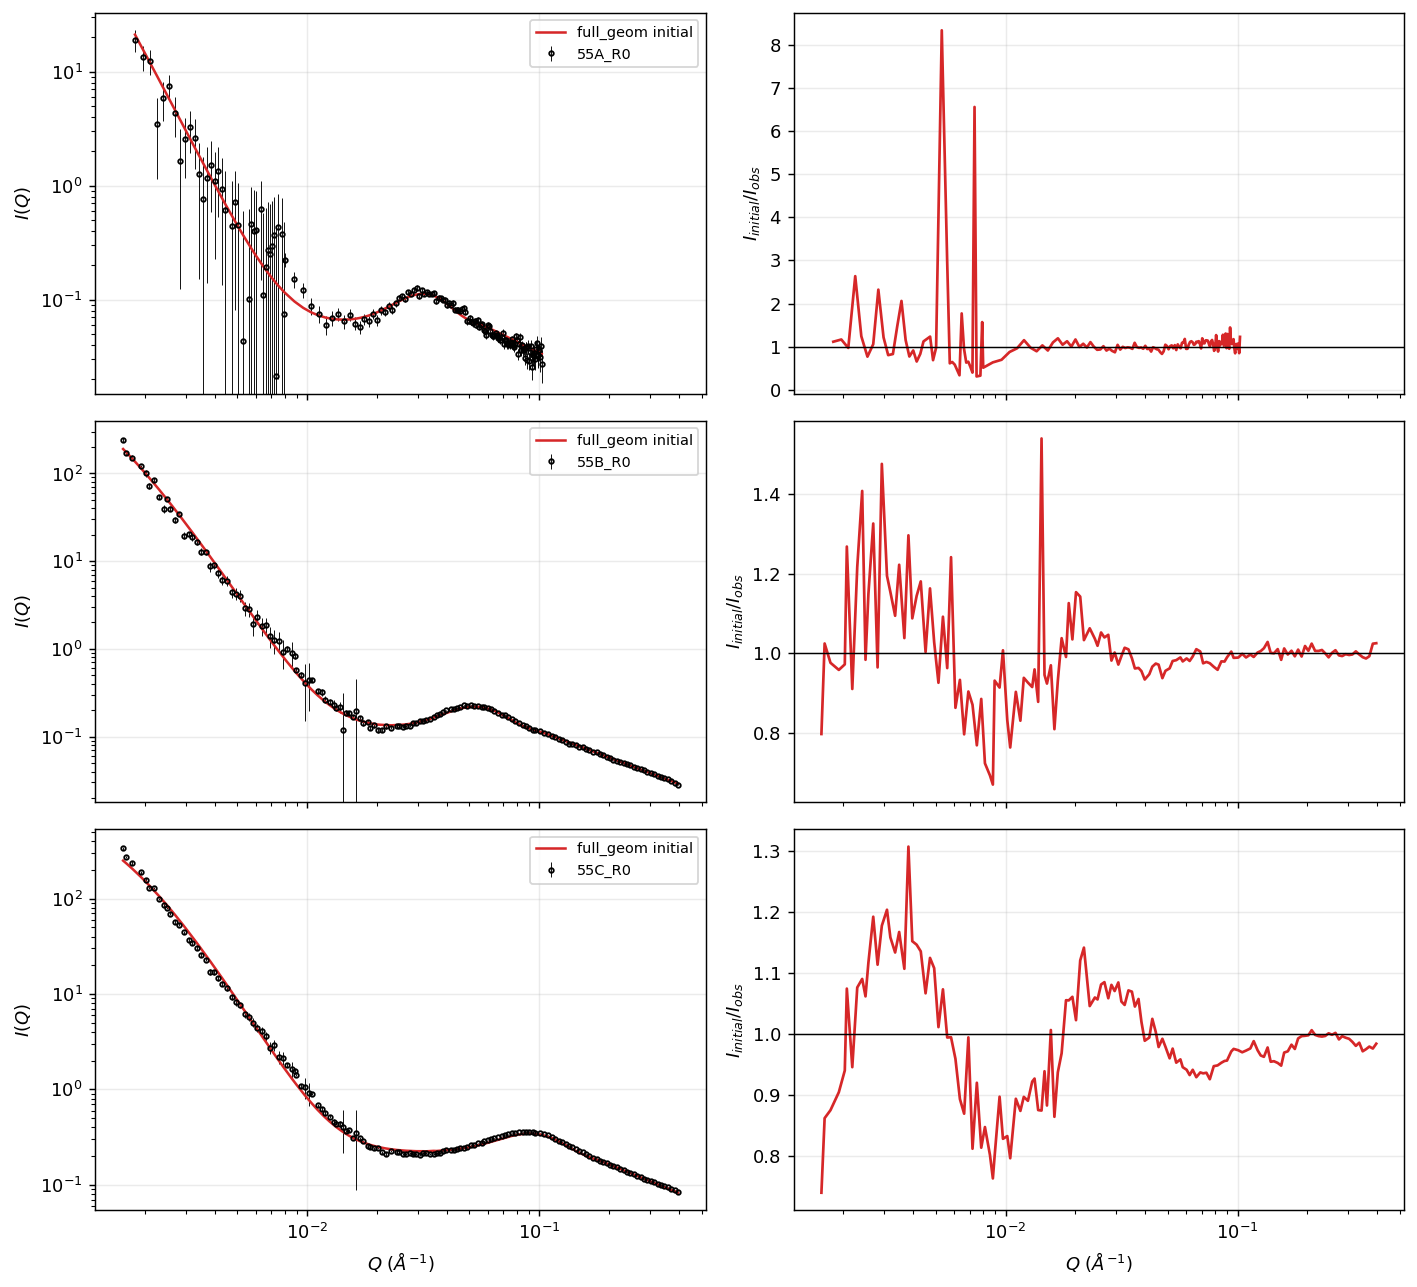

In [4]:
fig, axes = plt.subplots(len(SAMPLES), 2, figsize=(11, 10), sharex="col")
for row, tag in enumerate(SAMPLES):
    model = initial_models[tag]
    axes[row, 0].errorbar(model.q, model.intensity, yerr=model.error, fmt="o", ms=2.5, lw=0.5, color="k", markerfacecolor="none", label=tag)
    axes[row, 0].plot(model.q, model.model, color="C3", lw=1.4, label=f"{STRETCH_MODEL} initial")
    axes[row, 0].set(xscale="log", yscale="log", ylabel=r"$I(Q)$")
    axes[row, 0].legend(fontsize=8)
    axes[row, 1].semilogx(model.q, model.model/model.intensity, color="C3")
    axes[row, 1].axhline(1.0, color="k", lw=0.8)
    axes[row, 1].set(ylabel=r"$I_{initial}/I_{obs}$")
axes[-1, 0].set_xlabel(r"$Q$ ($\AA^{-1}$)")
axes[-1, 1].set_xlabel(r"$Q$ ($\AA^{-1}$)")
fig.tight_layout()
fig.savefig(OUTPUT_DIR/f"yyw_{FIT_TAG}_initial_models.png")
plt.show()


## Full-geometric fit

The current YYW affine parameters are starting values, not fixed constraints. The fit varies `k_eff`, `r_sigma_k`, `k_H_over_k`, `b`, and `stretch_ratio`; the overall intensity scale is solved analytically at every trial. The established high-$Q$ coefficient anchor is retained.


In [5]:
fit_results = {}

def save_fit_result(tag, result):
    parameter_path = OUTPUT_DIR/f"{tag}_{FIT_TAG}_fit_parameters.csv"
    curve_path = OUTPUT_DIR/f"{tag}_{FIT_TAG}_fit_curve.csv"
    with parameter_path.open("w", newline="", encoding="utf-8") as handle:
        writer = csv.writer(handle); writer.writerow(["name", "value"]); writer.writerows(result.parameters.items())
    np.savetxt(
        curve_path,
        np.column_stack([result.q, result.intensity, result.error, result.model, result.model/result.intensity]),
        delimiter=",", header="Q,I_obs,err,I_fit,I_fit_over_I_obs", comments="",
    )
    return parameter_path, curve_path

if RUN_FITS:
    for tag in SAMPLES:
        print(f"[full geom] {tag}")
        sample_distribution_set = {"r_sigma_k": {
            "initial": fit_initials[tag]["r_sigma_k"],
            "bounds": fit_bounds_by_sample[tag]["r_sigma_k"],
        }}
        result = cf.fit_heterogeneous_line_least_squares(
            profiles[tag], q_bounds=FIT_Q_BOUNDS, initial=fit_initials[tag],
            model_mode=MODEL_MODE, lowq_kappa_anchor=None,
            highq_coefficient_anchor=anchors[tag]["high"].parameters["coefficient"],
            bounds=fit_bounds_by_sample[tag], model_settings=fit_model_settings,
            distribution_parameter_set=sample_distribution_set, 
            constraints=cf.LineFitConstraints(), max_nfev=MAX_NFEV,
            anchor_weight=HIGHQ_ANCHOR_WEIGHT,
            log_error_floor=LOG_ERROR_FLOOR, affine_stretch=True,
        )
        result.parameters["rms_relative"] = float(np.sqrt(np.mean((result.model/result.intensity-1.0)**2)))
        fit_results[tag] = result
        save_fit_result(tag, result)
        print(f"  success={result.success}; nfev={result.nfev}; cost={result.cost:.8g}; RMSrel={result.parameters['rms_relative']:.6g}")
        for name in fit_bounds_by_sample[tag]:
            print(f"  {name:16s} {result.parameters[name]:.8g}")
else:
    print("[status] fits not run; inspect initial models and set RUN_FITS=True")


[full geom] 55A_R0
  success=True; nfev=23; cost=93.575989; RMSrel=0.798242
  k_eff            0.019314817
  r_sigma_k        0.20782318
  stretch_ratio    1.1935204
  k_H_over_k       0.059140859
  b                0.10860814
[full geom] 55B_R0
  success=True; nfev=14; cost=123.93878; RMSrel=0.115197
  k_eff            0.032492166
  r_sigma_k        0.21039694
  stretch_ratio    1.2611849
  k_H_over_k       0.08877335
  b                -0.76346689
[full geom] 55C_R0
  success=True; nfev=23; cost=234.83564; RMSrel=0.0886221
  k_eff            0.057046725
  r_sigma_k        0.2430627
  stretch_ratio    1.2862572
  k_H_over_k       0.055864105
  b                -1.7370542


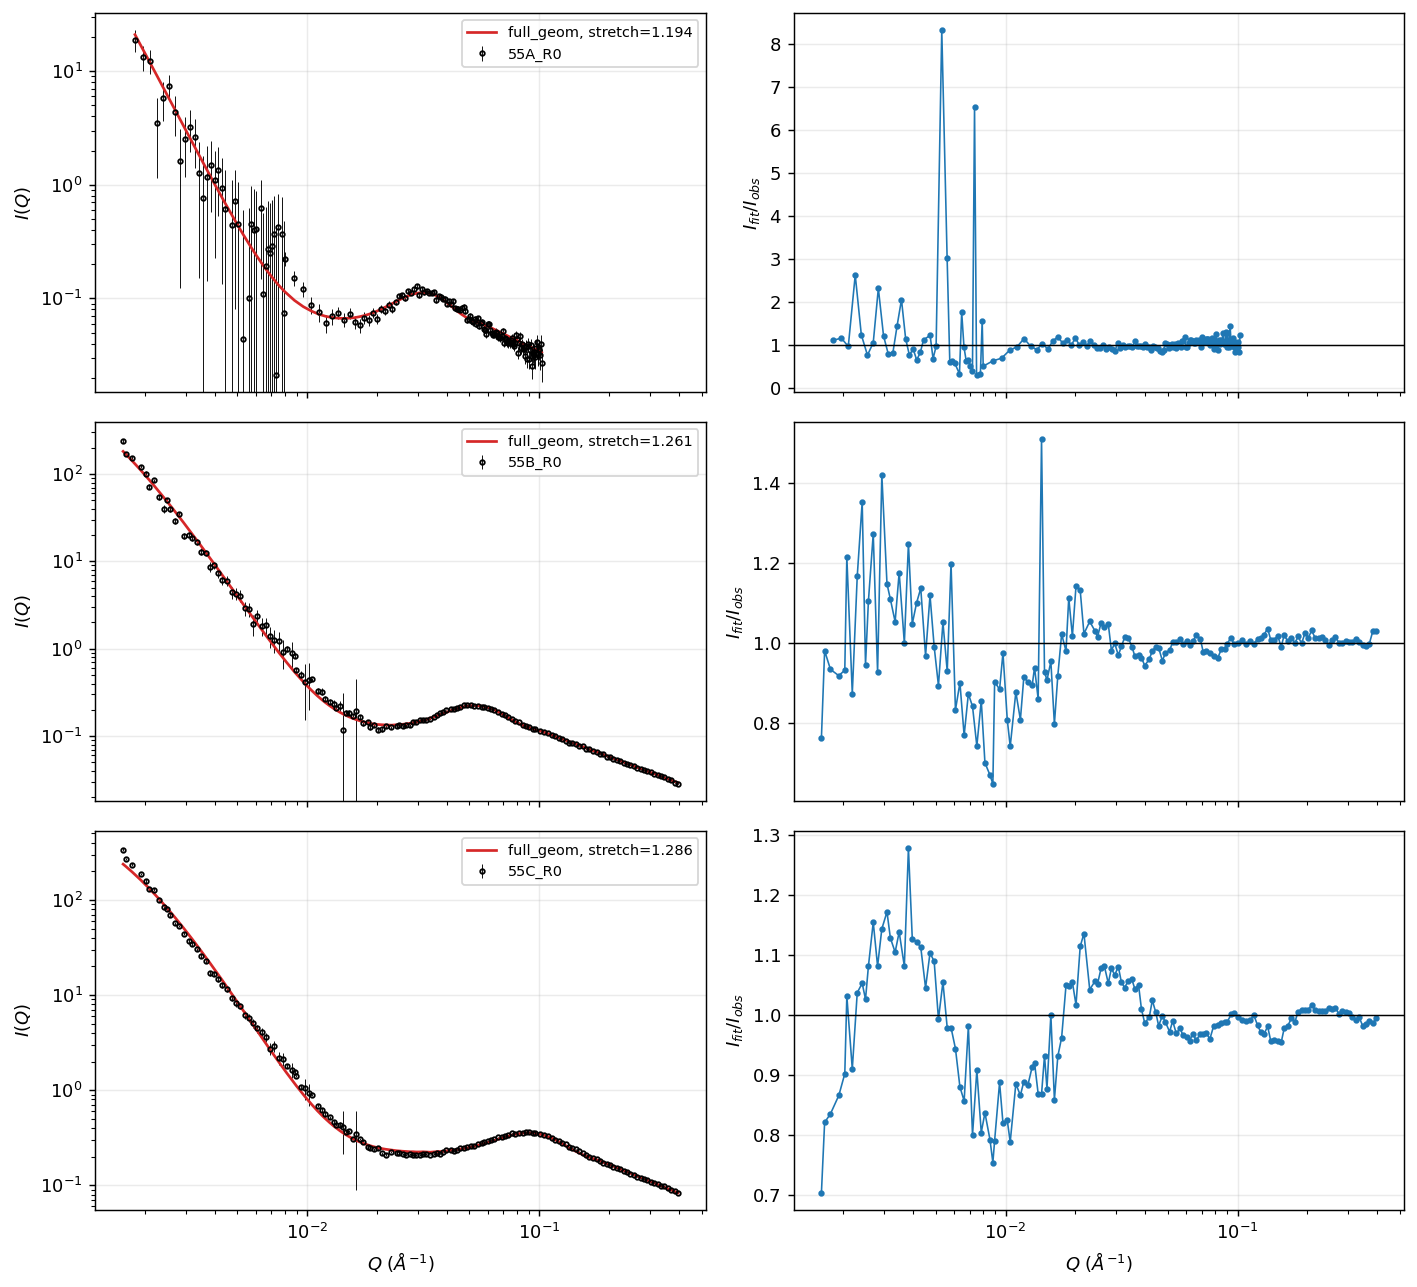

In [6]:
if RUN_FITS:
    summary_names = ["k_eff", "mean_k", "r_sigma_k", "k_H_over_k", "b", "stretch_ratio", "line_density_geometric", "scale", "rms_relative"]
    with (OUTPUT_DIR/f"yyw_{FIT_TAG}_fit_summary.csv").open("w", newline="", encoding="utf-8") as handle:
        writer = csv.writer(handle); writer.writerow(["sample", *summary_names])
        for tag, result in fit_results.items(): writer.writerow([tag, *[result.parameters[name] for name in summary_names]])
    fig, axes = plt.subplots(len(SAMPLES), 2, figsize=(11, 10), sharex="col")
    for row, tag in enumerate(SAMPLES):
        result = fit_results[tag]
        axes[row, 0].errorbar(result.q, result.intensity, yerr=result.error, fmt="o", ms=2.5, lw=0.5, color="k", markerfacecolor="none", label=tag)
        axes[row, 0].plot(result.q, result.model, color="C3", lw=1.5, label=f"{STRETCH_MODEL}, stretch={result.parameters['stretch_ratio']:.3f}")
        axes[row, 0].set(xscale="log", yscale="log", ylabel=r"$I(Q)$")
        axes[row, 0].legend(fontsize=8)
        axes[row, 1].semilogx(result.q, result.model/result.intensity, "o-", ms=2.5, lw=0.9)
        axes[row, 1].axhline(1.0, color="k", lw=0.8)
        axes[row, 1].set(ylabel=r"$I_{fit}/I_{obs}$")
    axes[-1, 0].set_xlabel(r"$Q$ ($\AA^{-1}$)")
    axes[-1, 1].set_xlabel(r"$Q$ ($\AA^{-1}$)")
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR/f"yyw_{FIT_TAG}_fits.png")
    plt.show()
